In [1]:
%pip install -q ultralytics
print("Done")

Note: you may need to restart the kernel to use updated packages.
Done



**Dataset used:** Fruit Detection Dataset — 6 classes: `Apple, Banana, Grape,
Orange, Pineapple, Watermelon`, ~8,479 images total, already annotated in
**YOLO format** (`.txt` label files with normalized
`class x_center y_center width height`), split into `train/valid/test`.

- Original source: Kaggle — ["Fruit Detection" by Lakshay Tyagi](https://www.kaggle.com/datasets/lakshaytyagi01/fruit-detection)
- Downloaded here via its public YOLO-format mirror on GitHub
  (`lightly-ai/dataset_fruits_detection`), since direct Kaggle/Roboflow access
  was not reachable from the execution environment this notebook was
  originally built in. The data itself is identical, just in YOLO `.txt`
  format already.


In [ ]:
import os
# checks for the dataset file exits
DATASET_DIR = "dataset_fruits_detection" 

if not os.path.isdir(DATASET_DIR): #runs a shell command to clone the GitHub repo containing the fruit dataset.
    !git clone --depth 1 https://github.com/lightly-ai/dataset_fruits_detection.git
else:
    print("Dataset already present.")

Dataset already present.


In [ ]:
import yaml #YOLO datasets include yaml to describe the dataset structure, including class names and number of classes. 
# The code reads this yaml file to extract and print the number of classes and their names.

with open(f"{DATASET_DIR}/data.yaml") as f:
    data_cfg = yaml.safe_load(f) #parses yaml file and loads it into a Python dictionary.

print("Number of classes:", data_cfg["nc"]) #number of classes
print("Class names:", data_cfg["names"]) #list of class name strings

Number of classes: 6
Class names: ['Apple', 'Banana', 'Grape', 'Orange', 'Pineapple', 'Watermelon']


## 6. Load a Pre-trained YOLO Model

We load `yolov8n.pt` — the nano YOLOv8 model pre-trained on the COCO dataset
(80 classes). Ultralytics automatically downloads the weights the first time.

In [ ]:
from ultralytics import YOLO
# loads the YOLOv8-nano model pretrained on COCO (80 general classes)
model = YOLO("yolov8n.pt")
print(f"Loaded model with {len(model.names)} COCO classes.")
print(model.names)

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\HP\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loaded model with 80 COCO classes.
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'k

Prints how many classes the model knows (80) this is a different, larger class set than the fruit dataset's 6 classes, which becomes the whole point of this experiment (seeing how well a generic model handles a specialized fruit task).

## 7. Prepare Sample Images

We pick 8 sample images from the `test/` split, one (or more) per fruit class,
so we can compare the model's predictions against the known ground-truth fruit
in each image.

In [ ]:
import shutil

SAMPLES_DIR = "samples" #Creates a samples/ folder to hold a small curated subset of test images
os.makedirs(SAMPLES_DIR, exist_ok=True)

# (image filename without extension, ground-truth label used only for our own reference)
sample_images = {
    "000d9c59687b509b_jpg.rf.c338360b3dfe1953a5d266ee861d7e79": "Apple",
    "0074691e66aa85c0_jpg.rf.2fc1e81bbe5377b89f9c912c52ff7905": "Apple_Banana",
    "006e0a3d99d16d60_jpg.rf.258f5af33beab4d59918218c732de430": "Grape",
    "000e4e7ed48c932d_jpg.rf.8233751e16b32b9470e45c6135c8f8c7": "Orange",
    "00a70c466ad1fe24_jpg.rf.cf298c47a082719e705775c1ec343775": "Pineapple",
    "000aee0af66d4237_jpg.rf.6b99256606e5b7a1ede8b833a87196a7": "Watermelon",
    "00d843af60eecf7c_jpg.rf.868bfcbb7f5f2cc63f82441d7ddcf577": "Banana",
    "037d96c648255043_jpg.rf.7a48f71356de00f7fab42bcd8f0c8bb1": "Watermelon",
}

for base in sample_images: #The loop copies each selected image from the dataset's test/images/ folder into samples/,
    # skipping any that are already copied (if not os.path.exists(dst)
    src = f"{DATASET_DIR}/test/images/{base}.jpg"
    dst = f"{SAMPLES_DIR}/{base}.jpg"
    if not os.path.exists(dst):
        shutil.copy(src, dst)

print(f"{len(sample_images)} sample images ready in '{SAMPLES_DIR}/'")

8 sample images ready in 'samples/'


## 8. Run Inference

Run the pre-trained model on the sample images and save the annotated
(bounding-box) images.

In [ ]:
results = model.predict(
    source=SAMPLES_DIR, #tells YOLO to run detection on all images in the samples/ folder
    conf=0.25, # sets the confidence threshold: only detections the model is at least 25% confident about are kept/reported. Lower threshold = more (but less certain) detections.
    save=True, 
    project="outputs",
    name="predictions",
    exist_ok=True,
)


image 1/8 c:\Users\HP\Desktop\MLB-Internship\Day13\samples\000aee0af66d4237_jpg.rf.6b99256606e5b7a1ede8b833a87196a7.jpg: 640x640 1 person, 1031.4ms
image 2/8 c:\Users\HP\Desktop\MLB-Internship\Day13\samples\000d9c59687b509b_jpg.rf.c338360b3dfe1953a5d266ee861d7e79.jpg: 640x640 5 persons, 1 bicycle, 1 apple, 1833.5ms
image 3/8 c:\Users\HP\Desktop\MLB-Internship\Day13\samples\000e4e7ed48c932d_jpg.rf.8233751e16b32b9470e45c6135c8f8c7.jpg: 640x640 1 orange, 903.6ms
image 4/8 c:\Users\HP\Desktop\MLB-Internship\Day13\samples\006e0a3d99d16d60_jpg.rf.258f5af33beab4d59918218c732de430.jpg: 640x640 1 bowl, 1 apple, 2188.6ms
image 5/8 c:\Users\HP\Desktop\MLB-Internship\Day13\samples\0074691e66aa85c0_jpg.rf.2fc1e81bbe5377b89f9c912c52ff7905.jpg: 640x640 2 bananas, 5 apples, 2 oranges, 563.8ms
image 6/8 c:\Users\HP\Desktop\MLB-Internship\Day13\samples\00a70c466ad1fe24_jpg.rf.cf298c47a082719e705775c1ec343775.jpg: 640x640 1 person, 1610.2ms
image 7/8 c:\Users\HP\Desktop\MLB-Internship\Day13\samples\00d8

## 9. Detection Summary

Build a simple summary of every detected class + confidence, per image.

In [ ]:
import json
from pathlib import Path

summary = []
for r in results: #loops thru each result object
    image_name = Path(r.path).name #extract just the filename from the path
    detections = [ # creates a list of dictionaries for each detected object in the image, containing the class name and confidence score
        {"class": model.names[int(box.cls[0])], "confidence": round(float(box.conf[0]), 3)}
        for box in r.boxes
    ]
    gt_label = sample_images[image_name.replace(".jpg", "")] #extracts the ground-truth label for the image from the sample_images dictionary, using the image filename (without extension) as the key.
    summary.append({"image": image_name, "ground_truth": gt_label, "detections": detections})
    # Everything gets bundled into a dictionary and appended to the summary list building a structured record of predictions vs. ground truth for every image.
    print(f"[GT: {gt_label:15s}] {image_name} -> {detections}")

with open("detection_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

[GT: Watermelon     ] 000aee0af66d4237_jpg.rf.6b99256606e5b7a1ede8b833a87196a7.jpg -> [{'class': 'person', 'confidence': 0.3}]
[GT: Apple          ] 000d9c59687b509b_jpg.rf.c338360b3dfe1953a5d266ee861d7e79.jpg -> [{'class': 'person', 'confidence': 0.89}, {'class': 'person', 'confidence': 0.864}, {'class': 'person', 'confidence': 0.673}, {'class': 'person', 'confidence': 0.602}, {'class': 'bicycle', 'confidence': 0.507}, {'class': 'person', 'confidence': 0.499}, {'class': 'apple', 'confidence': 0.253}]
[GT: Orange         ] 000e4e7ed48c932d_jpg.rf.8233751e16b32b9470e45c6135c8f8c7.jpg -> [{'class': 'orange', 'confidence': 0.707}]
[GT: Grape          ] 006e0a3d99d16d60_jpg.rf.258f5af33beab4d59918218c732de430.jpg -> [{'class': 'bowl', 'confidence': 0.629}, {'class': 'apple', 'confidence': 0.31}]
[GT: Apple_Banana   ] 0074691e66aa85c0_jpg.rf.2fc1e81bbe5377b89f9c912c52ff7905.jpg -> [{'class': 'orange', 'confidence': 0.676}, {'class': 'apple', 'confidence': 0.656}, {'class': 'apple', 'confide

## 10. Visualize the Detection Results

Display each annotated image (with predicted bounding boxes) next to its
ground-truth fruit label.

Annotated images saved to: C:\Users\HP\Desktop\MLB-Internship\Day13\runs\detect\outputs\predictions


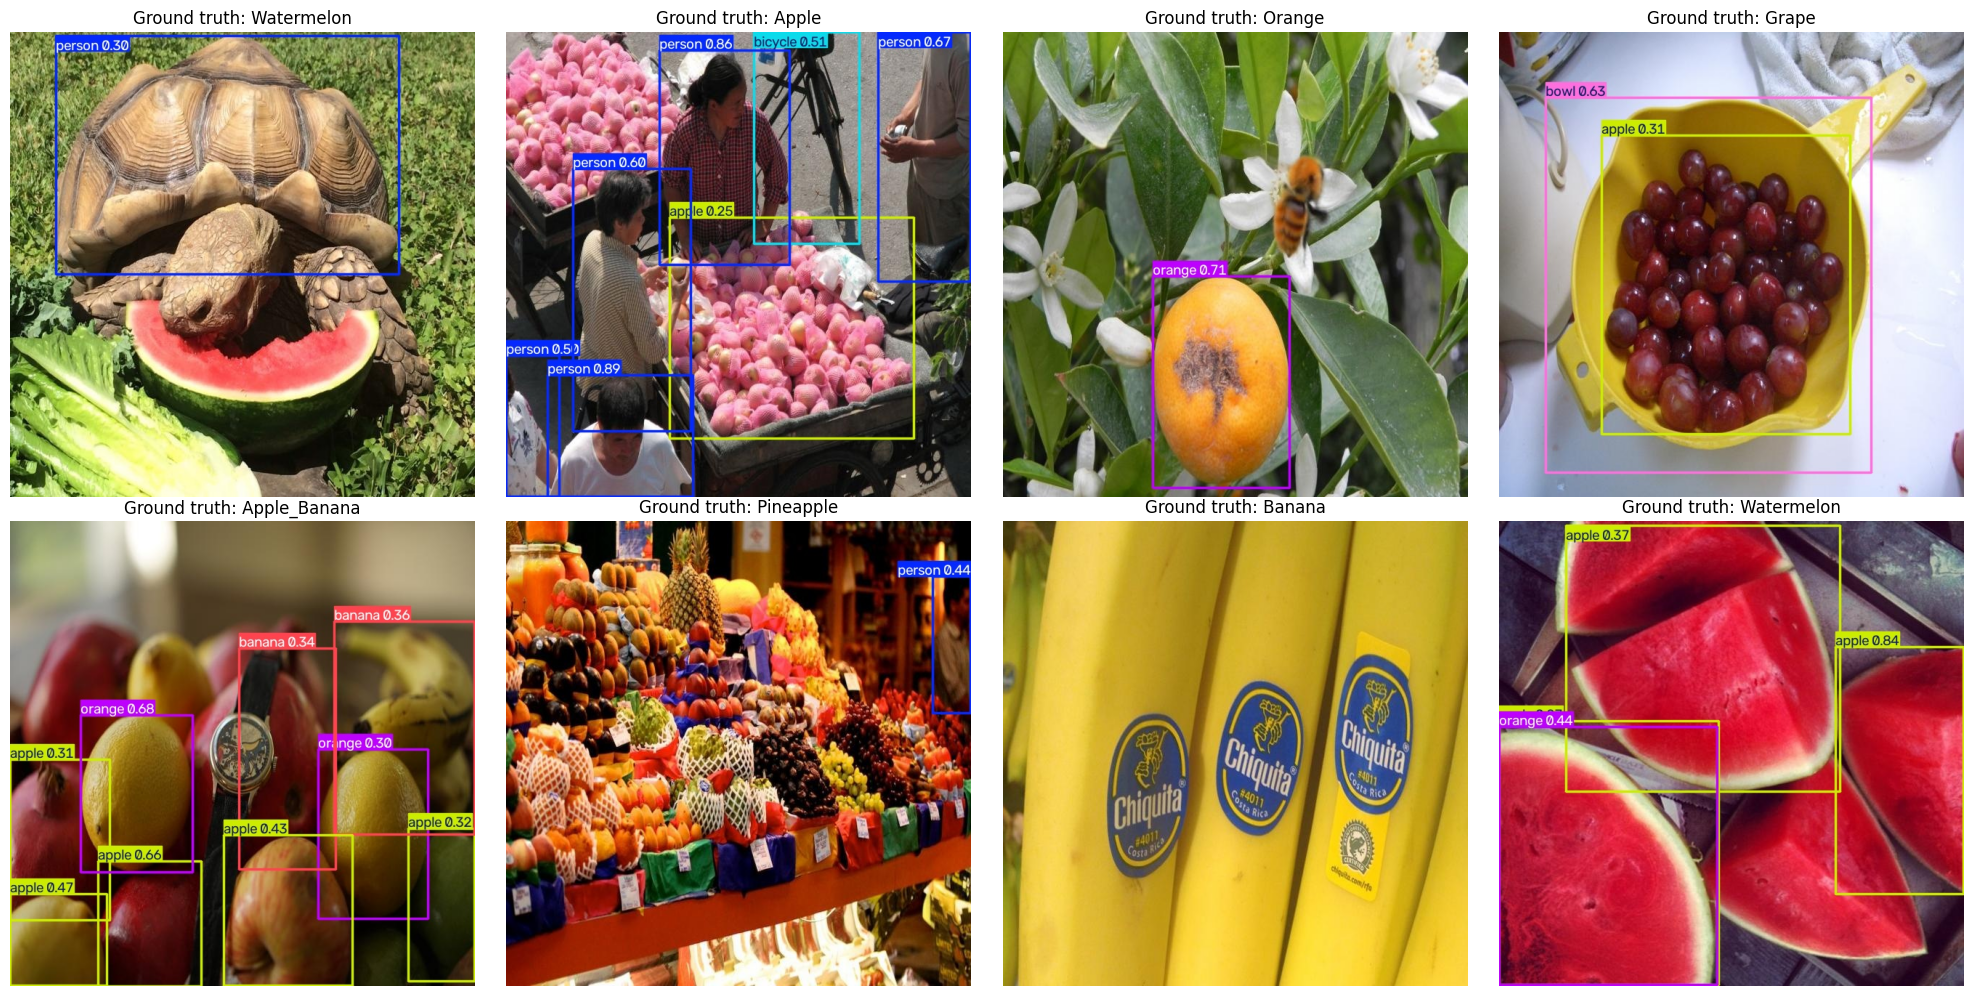

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

pred_dir = Path(results[0].save_dir)
print("Annotated images saved to:", pred_dir)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, item in zip(axes.flatten(), summary):
    img = Image.open(pred_dir / item["image"])
    ax.imshow(img)
    ax.set_title(f'Ground truth: {item["ground_truth"]}', fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.savefig(pred_dir / "comparison_grid.jpg", dpi=100, bbox_inches="tight")
plt.show()

## 11. What Objects Were Detected

Across the 8 sample images, the pre-trained COCO model detected:

In [9]:
from collections import Counter

class_counts = Counter()
zero_detections = 0
for item in summary:
    if not item["detections"]:
        zero_detections += 1
    for det in item["detections"]:
        class_counts[det["class"]] += 1

print("Detected class counts:", dict(class_counts))
print(f"Images with zero detections: {zero_detections}/{len(summary)}")

Detected class counts: {'person': 7, 'bicycle': 1, 'apple': 10, 'orange': 4, 'bowl': 1, 'banana': 2}
Images with zero detections: 1/8


| Image (ground-truth fruit) | Model's detections |
|---|---|
| Apple | person ×5, bicycle, apple (0.25) — apple detected but at low confidence, buried among people/bicycle in the scene |
| Apple + Banana | orange (0.68), apple ×5, banana ×2 — most fruits correctly found |
| Grape | bowl (0.63), apple (0.31) — **grape missed entirely** |
| Orange | orange (0.71) — correctly detected |
| Pineapple | person (0.44) — **pineapple missed entirely**, false "person" |
| Watermelon | person (0.30) — **watermelon missed entirely** |
| Banana | *no detections* — **banana missed entirely** |
| Watermelon | apple ×3, orange (0.44) — **watermelon misclassified as apples/orange** |

## 12. Observations

- **The out-of-the-box COCO model only "knows" 3 of the dataset's 6 fruits**
  (apple, banana, orange), because those are the only fruit classes in COCO's
  80-class vocabulary. Grape, pineapple, and watermelon have **no matching
  COCO class**, so the model either misses them completely or misclassifies
  them as the closest-looking known class (e.g., a watermelon slice being read
  as "apple"/"orange" due to similar round shape and color).
- **Apples and oranges were detected reliably** when clearly visible and
  reasonably sized in the frame, with confidences from ~0.25 up to 0.84.
- **Cluttered/multi-object scenes were harder**: the fruit-stall image full of
  people and a bicycle correctly detected people and the bicycle, but only
  found one apple at low confidence — small, overlapping fruit in a busy
  background is a common failure mode for a general-purpose model that wasn't
  trained specifically for this dataset.
- **False positives on unseen classes**: for pineapple and watermelon images,
  the model output a low-confidence "person" detection instead of the actual
  fruit — a sign the model is trying to fit the object to its known 80 classes
  rather than truly "not detecting."
- **Takeaway**: a pre-trained COCO model is a fast, zero-effort way to get
  partial fruit detection, but for reliable detection of all 6 classes
  (especially grape, pineapple, watermelon) the model would need to be
  **fine-tuned on this dataset**, e.g.:
  ```python
  model.train(data=f"{DATASET_DIR}/data.yaml", epochs=50, imgsz=640)
  ```
  rather than used purely off-the-shelf.
